In [ ]:
!pip install torch transformers pandas
!pip install Keras-Preprocessing
!pip install datasets
!pip install catboost

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix
import os
os.environ["OMP_NUM_THREADS"] = "1" # export OMP_NUM_THREADS=1
os.environ["OPENBLAS_NUM_THREADS"] = "1" # export OPENBLAS_NUM_THREADS=1
os.environ["MKL_NUM_THREADS"] = "1" # export MKL_NUM_THREADS=1
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" # export VECLIB_MAXIMUM_THREADS=1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df.groupby('country')['country'].transform('size').between(100,200)]

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 457 entries, 1498 to 58897
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            457 non-null    object 
 1   country                             457 non-null    object 
 2   contest_url                         457 non-null    object 
 3   num_of_contest                      457 non-null    int64  
 4   is_weekly                           457 non-null    bool   
 5   rank                                457 non-null    int64  
 6   score                               457 non-null    int64  
 7   question_number                     457 non-null    int64  
 8   question_language                   457 non-null    object 
 9   question_code                       457 non-null    object 
 10  number_of_lines                     457 non-null    int64  
 11  names_set                           457 non-n

In [ ]:
leetcode_questions_df.country.value_counts()

,count
country,
Canada,176
China,173
Japan,108


In [ ]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,...,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000
mean,321.159737,382.754923,16.899344,3.420131,49.603939,39.798687,22.238512,1.927790,3.656455,4.339168,...,0.047615,0.090516,0.107380,0.072315,3243.236324,2270.306346,1133.096280,0.004917,1411.503282,19.512035
std,107.243649,337.303148,2.540622,0.494121,28.635539,13.054666,8.311771,1.402236,2.720562,3.294210,...,0.024034,0.060854,0.069130,0.128391,1575.806621,1300.394290,951.283685,0.017807,783.430759,11.060657
min,116.000000,1.000000,11.000000,3.000000,6.000000,11.000000,5.000000,1.000000,0.000000,0.000000,...,0.012500,0.000000,0.000000,0.000000,417.000000,179.000000,0.000000,0.000007,109.000000,1.000000
25%,367.000000,106.000000,17.000000,3.000000,30.000000,31.000000,16.000000,1.000000,2.000000,2.000000,...,0.030303,0.047619,0.058824,0.000000,1984.000000,1239.000000,434.000000,0.000032,894.000000,11.000000
50%,374.000000,277.000000,18.000000,3.000000,42.000000,38.000000,21.000000,1.000000,3.000000,4.000000,...,0.040000,0.080000,0.095238,0.000000,3104.000000,1947.000000,860.000000,0.000265,1268.000000,16.000000
75%,383.000000,579.000000,18.000000,4.000000,63.000000,46.000000,27.000000,2.000000,5.000000,6.000000,...,0.058824,0.116279,0.140000,0.108108,4456.000000,3213.000000,1593.000000,0.000769,1784.000000,29.000000
max,390.000000,1222.000000,20.000000,4.000000,201.000000,99.000000,54.000000,15.000000,15.000000,26.000000,...,0.223881,0.400000,0.416667,0.803922,7595.000000,5356.000000,4686.000000,0.161798,5943.000000,34.000000


In [ ]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df.country

In [ ]:
import re

def remove_class_definition(java_code):
    # Regular expression to match the class definition
    # This regex will match 'class Solution {' and capture everything inside until the last closing brace '}'
    class_pattern = r'class\s+Solution\s*{(.*?)}\s*$'

    # Use re.DOTALL to allow '.' to match newlines as well
    match = re.search(class_pattern, java_code, re.DOTALL)

    if match:
        # Get the contents inside the class
        inside_class = match.group(1)

        # Strip leading and trailing whitespaces or newlines
        stripped_code = inside_class.strip()

        return stripped_code
    else:
        # If pattern does not match, return original code
        return java_code

X.question_code = X.question_code.apply(remove_class_definition)

In [ ]:
X.question_number = X.question_number.astype("category")

In [ ]:
X_nontext=X[['question_number', 'question_finish_time_total_seconds', 'number_of_lines',
            'token_count', 'variables_count', 'function_count', 'loop_count',
            'condition_count', 'single_line_comment_density',
            'multiline_comment_density', 'function_density', 'loop_density',
            'condition_density', 'comment_tokens_density']]

one_hot = pd.get_dummies(X_nontext.question_number, prefix='question_number', drop_first=True)
X_nontext = X_nontext.drop('question_number', axis=1)
X_nontext = pd.concat([X_nontext, one_hot], axis=1)

X_nontext.question_finish_time_total_seconds = X_nontext.question_finish_time_total_seconds.astype(int)

X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 457 entries, 1498 to 58897
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   question_finish_time_total_seconds  457 non-null    int64  
 1   number_of_lines                     457 non-null    int64  
 2   token_count                         457 non-null    int64  
 3   variables_count                     457 non-null    int64  
 4   function_count                      457 non-null    int64  
 5   loop_count                          457 non-null    int64  
 6   condition_count                     457 non-null    int64  
 7   single_line_comment_density         457 non-null    float64
 8   multiline_comment_density           457 non-null    float64
 9   function_density                    457 non-null    float64
 10  loop_density                        457 non-null    float64
 11  condition_density                   457 non-n

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)
X_train_nontext, X_test_nontext, _, _ = train_test_split(X_nontext, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)
X_train_nontext, X_valid_nontext, _, _ = train_test_split(X_train_nontext, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [ ]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_valid = enc.transform(y_valid)
y_test = enc.transform(y_test)

In [ ]:
num_labels = len(enc.classes_)
num_labels

3

## CatBoostClassifier

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [ ]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',SVC(random_state=42))])

In [ ]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.38546626984126986


In [ ]:
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto'],
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_weighted')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_svc = grid_search.best_estimator_
y_cat_train_pred = best_svc.predict(X_train_nontext)
y_cat_test_pred = best_svc.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_cat_test_pred, average = 'weighted'))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters found:  {'classifier__C': 10, 'classifier__gamma': 'scale'}
Best F1 score found:  0.38562198420390204
Test set F1 score:  0.4304875378244944


              precision    recall  f1-score   support

      Canada       0.44      0.54      0.49        35
       China       0.41      0.34      0.38        35
       Japan       0.45      0.41      0.43        22

    accuracy                           0.43        92
   macro avg       0.44      0.43      0.43        92
weighted avg       0.43      0.43      0.43        92

f1_score :  0.4304875378244944


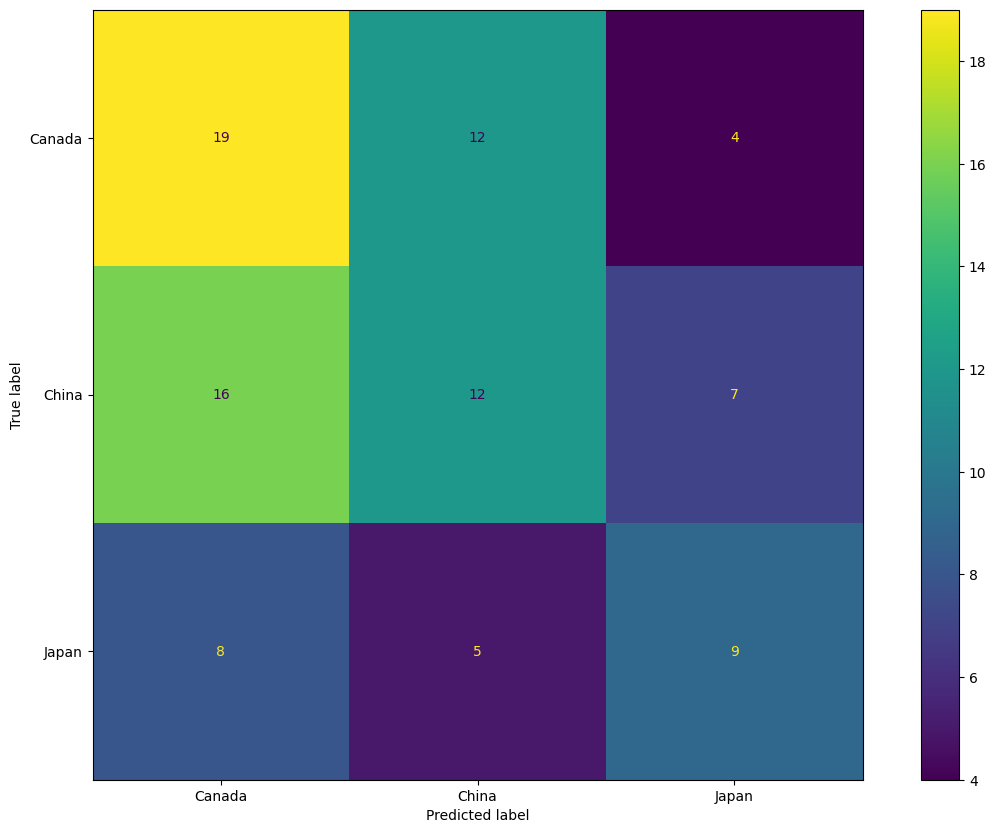

In [ ]:
print(classification_report(y_test, y_cat_test_pred, target_names=enc.classes_.tolist()))

print("f1_score : ",f1_score(y_test, y_cat_test_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_cat_test_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

## CodeBert

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Define the tokenizer and the model
model_name = "neulab/codebert-java"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Using device: cuda


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkp

In [ ]:
# define the dataset
class CodeDataset(Dataset):
    def __init__(self, code_series, country_series):
        self.samples = [(code, country_series[index]) for index, code in code_series.items()]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        code, label = self.samples[index]
        inputs = tokenizer.encode_plus(code, padding='max_length', max_length=512, truncation=True)
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Define the training dataset and dataloader
train_dataset = CodeDataset(X_train_text.reset_index(drop=True), y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = CodeDataset(X_valid_text.reset_index(drop=True), y_valid)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

# Define the testing dataset and dataloader
test_dataset = CodeDataset(X_test_text.reset_index(drop=True), y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Step 1: Calculate class weights based on your dataset
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# Step 2: Define a custom Trainer to incorporate class weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Define the weighted loss
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=40,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.05,
    logging_dir='./logs',
    logging_steps=10,
    optim='adamw_torch',
    learning_rate=1e-5,
    save_total_limit=2,
    metric_for_best_model='f1',
    evaluation_strategy='epoch',  # Evaluate at the end of each epoch
    save_strategy='epoch',        # Save the model at the end of each epoch
    load_best_model_at_end=True,  # Load the best model when early stopping is triggered
    lr_scheduler_type='cosine',   # Cosine learning rate schedule
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Define early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=1e-3
)

In [ ]:
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    f1 = f1_score(p.label_ids, preds, average='macro')  # Use macro average for multiclass classification
    return {"f1": f1}

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]  # Add the early stopping callback
)

In [ ]:
# Train the model with the pre-defined parameters
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,1.098700,1.112560,0.273927
2,1.084400,1.108590,0.299389
3,1.072200,1.101240,0.282761
4,1.067800,1.090793,0.288424
5,1.043700,1.074512,0.362750
6,1.000400,1.057435,0.397235
7,0.965300,1.037284,0.418182
8,0.932600,1.016333,0.430952
9,0.884500,1.001203,0.449754
10,0.896100,0.994999,0.449754


TrainOutput(global_step=560, training_loss=0.6518825976976327, metrics={'train_runtime': 596.4478, 'train_samples_per_second': 21.393, 'train_steps_per_second': 1.341, 'total_flos': 2350129047146496.0, 'train_loss': 0.6518825976976327, 'epoch': 28.0})

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_test_pred = []
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_test_pred += predictions.tolist()

              precision    recall  f1-score   support

      Canada       0.76      0.89      0.82        35
       China       0.90      0.80      0.85        35
       Japan       0.90      0.82      0.86        22

    accuracy                           0.84        92
   macro avg       0.85      0.83      0.84        92
weighted avg       0.85      0.84      0.84        92

f1_score :  0.840472393103972


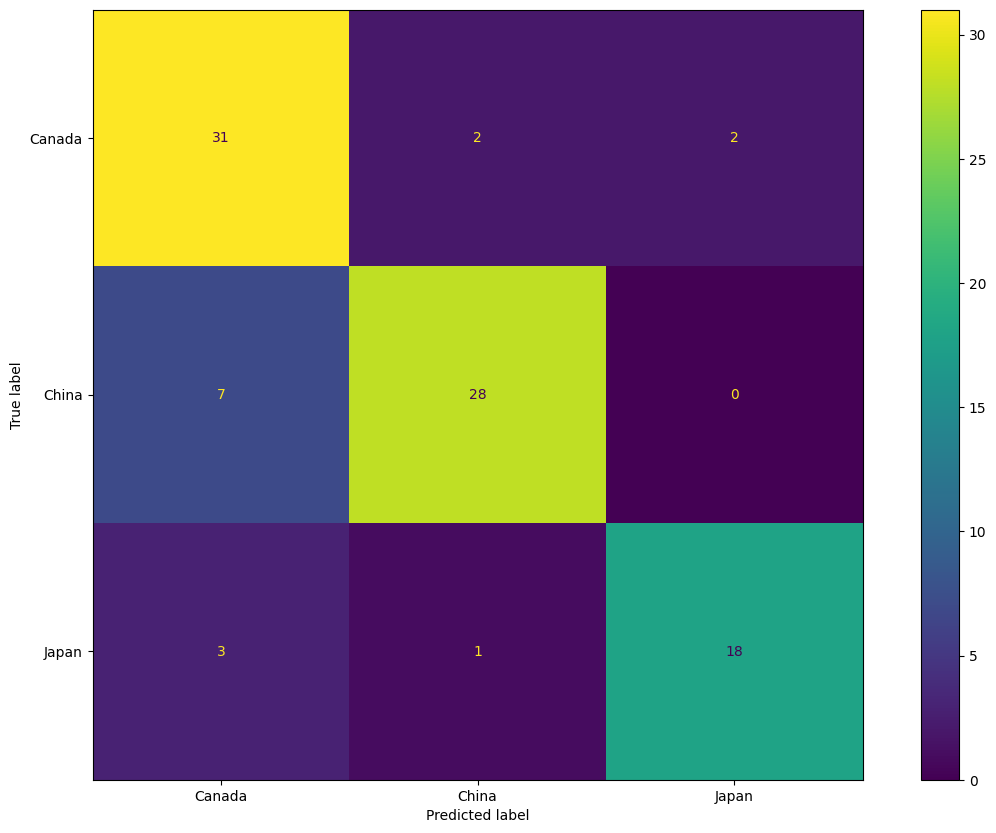

In [ ]:
print(classification_report(y_true, y_codebert_test_pred, target_names=enc.classes_.tolist()))

print("f1_score : ",f1_score(y_true, y_codebert_test_pred, average='macro'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_test_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_train_pred = []
with torch.no_grad():
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_train_pred += predictions.tolist()

              precision    recall  f1-score   support

      Canada       0.98      0.95      0.97       123
       China       0.95      1.00      0.97       121
       Japan       1.00      0.96      0.98        75

    accuracy                           0.97       319
   macro avg       0.98      0.97      0.97       319
weighted avg       0.97      0.97      0.97       319

f1_score :  0.9728071785652759


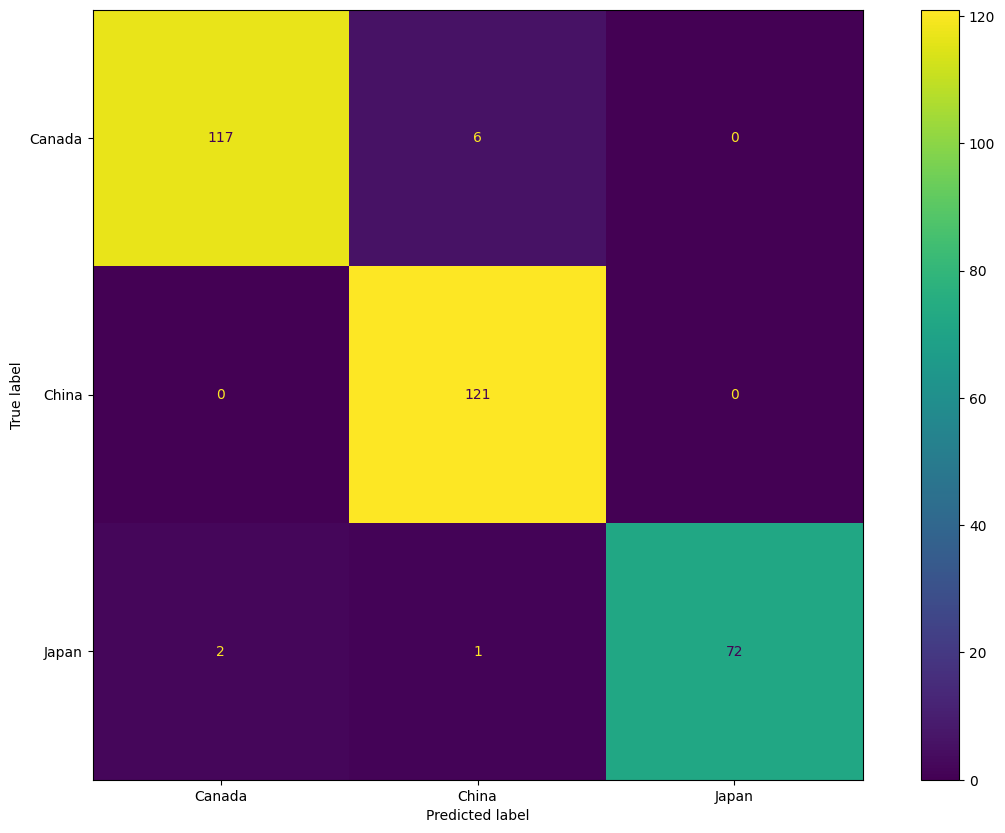

In [ ]:
print(classification_report(y_true, y_codebert_train_pred, target_names=enc.classes_.tolist()))

print("f1_score : ",f1_score(y_true, y_codebert_train_pred, average='macro'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_train_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# Ensemble

In [ ]:
from sklearn.linear_model import LogisticRegression

meta_X = np.column_stack((y_cat_train_pred.reshape(-1), y_codebert_train_pred))
meta_model = LogisticRegression()
meta_model.fit(meta_X, y_train)

# Final prediction
final_preds = meta_model.predict(np.column_stack((y_cat_test_pred.reshape(-1), y_codebert_test_pred)))

              precision    recall  f1-score   support

      Canada       0.44      0.54      0.49        35
       China       0.41      0.34      0.38        35
       Japan       0.45      0.41      0.43        22

    accuracy                           0.43        92
   macro avg       0.44      0.43      0.43        92
weighted avg       0.43      0.43      0.43        92

f1_score :  0.4302503052503053


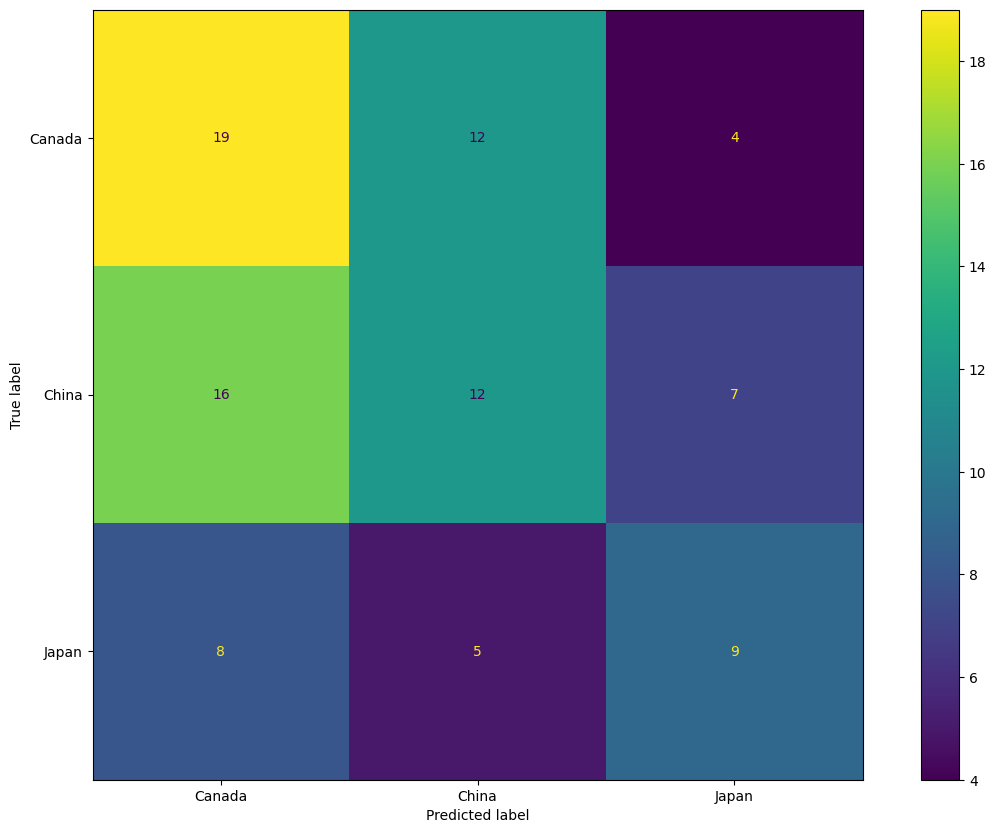

In [ ]:
print(classification_report(y_test, final_preds, target_names=enc.classes_.tolist()))

print("f1_score : ",f1_score(y_test, final_preds, average='macro'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, final_preds), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()